In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    MeanShift,
    estimate_bandwidth,
    AgglomerativeClustering,
)
from sklearn_extra.cluster import KMedoids
from sklearn.mixture import GaussianMixture

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from scipy.cluster.hierarchy import dendrogram

from Transformers import *  
import gower
from tqdm import tqdm
from prince import FAMD
import warnings
warnings.filterwarnings("ignore")
import pickle

## Wczytanie i obróbka danych na potrzeby modeli

In [2]:
df=pd.read_csv("data/TransformedData/train.csv") 

W przypadku KMedoids, DBScan i AgglomerativeClustering możliwe jest wykorzystanie danych mieszanych (tu: ciągłych i binarnych) wykorzystując policzoną już wcześniej macierz odległości. Wykorzystany [dystans Gowera](https://en.wikipedia.org/wiki/Gower%27s_distance), który choć nie jest metryką, sprawdza się w zadaniach klasteryzacji. Nadaje się on przy łączeniu różnych rodzajów zmiennych, dlatego sprawdzi się dobrze, w opozycji do np. metryki euklidesowej, która dla danych binarnych nie ma sensownego zastosowania.

In [3]:
df_gower = gower.gower_matrix(df)

In [4]:
df_gower

array([[0.        , 0.23566401, 0.22467615, ..., 0.18237813, 0.20867482,
        0.19516106],
       [0.23566401, 0.        , 0.13200328, ..., 0.15320182, 0.1447357 ,
        0.168295  ],
       [0.22467615, 0.13200328, 0.        , ..., 0.18531029, 0.19225663,
        0.19528948],
       ...,
       [0.18237813, 0.15320182, 0.18531029, ..., 0.        , 0.22219704,
        0.1584516 ],
       [0.20867482, 0.1447357 , 0.19225663, ..., 0.22219704, 0.        ,
        0.1340395 ],
       [0.19516106, 0.168295  , 0.19528948, ..., 0.1584516 , 0.1340395 ,
        0.        ]], dtype=float32)

W przypadku KMeans, GMM oraz Mean Shift nie jest możliwe zastosowanie innej metryki, dlatego przed przekazaniem danych wykonamy [FAMD](https://en.wikipedia.org/wiki/Factor_analysis_of_mixed_data) - proces podobny do PCA, z tym że działa dla zmiennych o różnych typach danych (tu: ciągłe i binarne), zwracając zmienne ciągłe, co będzie odpowiednie w przypadku ww. algorytmów.

In [5]:
df_ = df.copy()
for col in df_.columns:
    if df_[col].nunique() == 2 and df_[col].dtype in ['int64', 'float64']:
        df_[col] = df_[col].astype('category')


Zapiszemy transformator zfitowany FAMD, aby użyć go w innym pliku

In [ ]:
def save_famd(famd, filepath: str) -> None:
    with open(filepath, 'wb') as f:
        pickle.dump(famd, f)
    print(f"FAMD model saved to {filepath!r}")


In [7]:
n_components=21
random_state=42

famd = FAMD(n_components=n_components, random_state=random_state)
df_famd = famd.fit_transform(df_)
save_famd(famd, "data/TransformedData/famd_model.pkl")

FAMD model saved to 'data/TransformedData/famd_model.pkl'


Macierz przekształconych danych z pomocą FAMD

In [8]:
df_famd

component,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,2.708467,-0.551611,-4.593573,-0.474616,-0.794199,-0.844310,-0.406215,1.624301,2.294369,-0.725106,...,1.667961,-1.400625,-3.231245,-0.917264,1.213059,1.440065,-2.634625,1.564290,-1.110059,-1.865676
1,-1.230234,-2.691597,-0.953572,-0.851042,-0.252440,-0.623675,-0.397033,1.143526,2.414859,-1.077915,...,-1.443659,-1.402483,2.250456,0.823800,-0.794888,-0.685920,0.721030,-0.934872,0.311135,0.091214
2,-4.285434,-1.775497,-0.981312,-0.481878,-0.864703,0.755229,-0.513688,0.369535,2.106801,-0.595349,...,-3.302303,0.598952,-1.920008,-1.279666,1.855454,0.910709,0.219529,0.893472,0.368579,0.153717
3,-1.473172,-2.465286,-0.733479,-0.455937,1.288001,-0.525370,0.609727,-0.419375,-1.940307,0.249421,...,-1.127078,-2.127354,2.167356,1.350521,-1.857744,1.563836,-1.361330,-0.218255,0.012599,0.686631
4,3.101228,-3.272495,-1.183307,0.442535,1.050835,-0.781079,0.926418,-0.433668,-2.372339,0.141774,...,-1.930938,-1.513933,-1.844870,-1.012518,0.733157,-0.817284,-0.054345,-1.020862,-1.117428,1.418995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18897,0.926942,0.696530,0.833060,0.459306,0.531643,0.080195,0.762447,-0.781745,-2.188207,0.670189,...,-1.871740,1.832818,2.716338,-1.937075,1.976901,0.407265,-3.240684,-1.318736,-0.958633,-0.984778
18898,1.917439,-3.142769,-1.051925,6.437771,-1.642902,-3.162533,-0.413194,0.985695,2.314545,-0.590882,...,1.555198,-1.892576,-1.090966,2.732105,0.106117,0.583997,2.045215,-0.853103,-1.438383,-0.514820
18899,-0.084992,3.403583,-2.588215,-0.822847,-0.626209,-0.932004,-0.676723,1.447400,2.662079,-0.337692,...,1.951706,1.648863,1.635229,-0.623581,-0.275978,1.212318,-1.051318,-0.269795,0.478730,0.473269
18900,2.099308,-5.813337,4.086001,-0.755947,0.038582,-0.224933,-0.130254,1.170939,2.441368,-2.190897,...,2.952191,0.161904,-3.666159,0.149468,1.106505,-0.788951,-0.257128,-1.187782,0.773414,1.062667


Wyjaśnialność wariancji przez kolejne komponenty z FAMDa

In [ ]:
famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,10.451,9.77%,9.77%
1,9.431,8.81%,18.58%
2,8.155,7.62%,26.20%
3,7.638,7.14%,33.34%
4,7.514,7.02%,40.36%
5,7.251,6.78%,47.14%
6,7.189,6.72%,53.86%
7,7.023,6.56%,60.42%
8,6.980,6.52%,66.94%


In [ ]:
famd.column_contributions_.style.format('{:.0%}')

component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
variable,,,,,,,,,,,,,,,,,,,,,
ct_scale__skew__installment_sqrt,1%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,1%,0%,1%,30%,5%,8%,3%,0%,1%,0%
ct_scale__skew__total_acc_sqrt,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,2%,0%,0%,29%,7%,2%,2%,5%,12%
ct_pass__date__time_to_last_payment,0%,0%,0%,0%,1%,3%,0%,0%,0%,0%,0%,0%,0%,0%,1%,1%,0%,16%,6%,2%,62%
ct_pass__date__daysdiff_issue_pull,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,1%,12%,84%,1%,1%
ct_pass__progress__loan_to_income_full_period,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,52%,3%,0%,5%,0%,0%,0%
basic_num__dti,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,2%,11%,43%,6%,0%,7%,6%
basic_num__annual_income,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,5%,25%,31%,4%,0%,6%,0%
basic_num__emp_years,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,15%,1%,1%,0%,78%,3%
basic_num__sub_grade_numeric,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,3%,4%,8%,49%,5%,0%,13%


Poniżej przetestujemy 6 popularnych algorytmów klasteryzujących, wykorzystując dane z FAMD albo metrykę Gowera zgodnie z wcześniejszymi opisami

## AgglomerativeClustering

In [ ]:
def agglomerative_quality_plot(
    X,
    X_gower,
    n_clusters_range=range(2, 11),
    linkage="average",
    metric="precomputed",
    compute_metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
):
    
    results = {m: [] for m in compute_metrics}
    
    # print formatu tabeli 
    print(f"{'k':^3s} | {'clusters':^8s}" +
          "".join([f" | {m.replace('_',' ').title():^18s}" for m in compute_metrics]))
    print("-" * (12 + 22 * len(compute_metrics)))

    # iteracja po liczbie klastrów w celu wyznaczenia metryk
    for k in tqdm(n_clusters_range):
        
        kwargs = dict(n_clusters=k, linkage=linkage)
        
        if linkage != "ward":
            kwargs["metric"] = metric

        # stworzenie modelu
        model = AgglomerativeClustering(**kwargs)
        labels = model.fit_predict(X_gower)

        # wyznaczenie metryk do oceny optymalnej liczby klastrów
        for m in compute_metrics:
            if len(np.unique(labels)) <= 1:
                val = 0.0
            elif m == "silhouette":
                val = silhouette_score(X_gower, labels, metric=metric)
            elif m == "davies_bouldin":
                val = davies_bouldin_score(X, labels)
            elif m == "calinski_harabasz":
                val = calinski_harabasz_score(X, labels)
            else:
                raise ValueError(f"Nieznana metryka: {m}")
            results[m].append(val)

        
        row = f"{k:^3d} | {len(np.unique(labels)):8d}" + \
              "".join([f" | {results[m][-1]:18.4f}" for m in compute_metrics])
        print(row)

    #stworzenie wykresów to wizualizacji wyznaczonych metryk
    colors = {"silhouette": "tab:blue",
              "davies_bouldin": "tab:red",
              "calinski_harabasz": "tab:green"}

    n_rows = len(compute_metrics)
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 3 * n_rows), sharex=True)

    if n_rows == 1:
        axes = [axes]

    for ax, m in zip(axes, compute_metrics):
        ax.plot(
            list(n_clusters_range),
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axes[-1].set_xlabel("Liczba klastrów (k)")
    plt.suptitle(
        f"Agglomerative ({linkage}, metric={metric}) – jakościowe metryki vs. liczba klastrów",
        y=0.93,
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


wziąwszy pod uwagę wszystkie 3 metryki wybierzemy liczbę klastrów **n = 5**

 k  | clusters |     Silhouette     |   Davies Bouldin   | Calinski Harabasz 
------------------------------------------------------------------------------


 11%|█         | 1/9 [00:32<04:17, 32.25s/it]

 2  |        2 |             0.4002 |             0.6769 |             1.8979


 22%|██▏       | 2/9 [00:53<02:58, 25.51s/it]

 3  |        3 |             0.2706 |             2.3359 |             9.0987


...

 8  |        8 |             0.1063 |             2.8148 |            93.4181


 89%|████████▉ | 8/9 [02:39<00:17, 17.92s/it]

 9  |        9 |             0.0834 |             2.7138 |            83.0141


100%|██████████| 9/9 [02:56<00:00, 19.58s/it]

10  |       10 |             0.0726 |             2.7739 |            74.2051


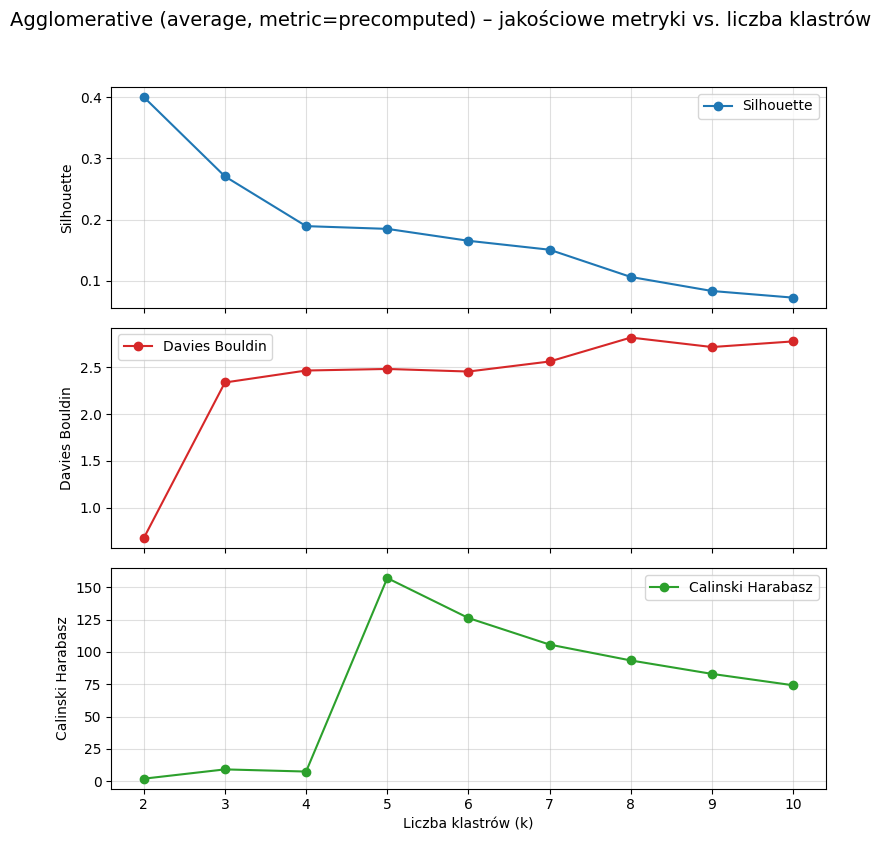

In [12]:
agglomerative_quality_plot(df, df_gower, n_clusters_range=range(2,11))

## Kmeans

In [ ]:
def KMeans_plotter(X, lower_bound=2, upper_bound=10):
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []
    
    # iteracja po liczbie klastrów w celu wyznaczenia metryk
    for i in tqdm(range(lower_bound, upper_bound + 1)):
        k = KMeans(n_clusters=i, random_state=42)
        k.fit(X)
        predicted = k.predict(X)
        inertia_list.append(k.inertia_)
        silhouette_list.append(silhouette_score(X, predicted))
    
    x_cord = np.arange(lower_bound, upper_bound + 1)
    
    
    
    # wykres wizualizujący metryki
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(x_cord, inertia_list, color='blue', linewidth=2, label='Inertia ')

    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)


    ax2 = ax1.twinx()

    ax2.plot(x_cord, silhouette_list, color='orange', linewidth=2, label='Silhouette ')

    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')


    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')

    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters')
    plt.tight_layout()


W KMeans wybierzemy **n = 3** klastry

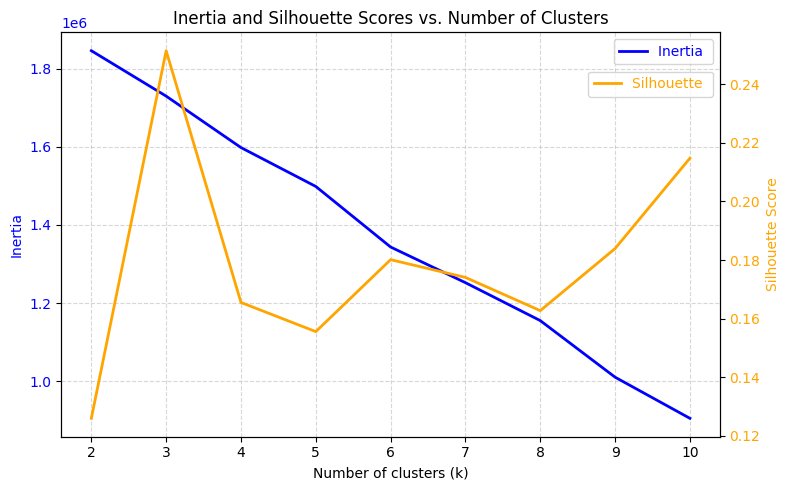

In [14]:
KMeans_plotter(df_famd)

## Kmedoids

In [ ]:
def KMedoids_plotter(X_gower, lower_bound=2, upper_bound=20, metric='precomputed'):
    
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []

    # iteracja po liczbie klastrów w celu wyznaczenia metryk
    for k in tqdm(range(lower_bound, upper_bound + 1)):
        
        kmedoids = KMedoids(
            n_clusters=k,
            metric=metric,
            random_state=42,
            method='pam'     
        )
        labels = kmedoids.fit_predict(X_gower)

        
        inertia_list.append(kmedoids.inertia_)

        
        unique_labels = np.unique(labels)
        if len(unique_labels) > 1:
            sil = silhouette_score(X_gower, labels, metric=metric)
        else:
            sil = 0.0
        silhouette_list.append(sil)

    x_cord = np.arange(lower_bound, upper_bound + 1)

    # wykresy wizualizujące klastry
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    ax1.plot(
        x_cord,
        inertia_list,
        color='blue',
        linewidth=2,
        marker='o',
        label='Inertia'
    )
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    
    ax2 = ax1.twinx()
    ax2.plot(
        x_cord,
        silhouette_list,
        color='orange',
        linewidth=2,
        marker='s',
        label='Silhouette'
    )
    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')
    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters (KMedoids)')
    plt.tight_layout()
    plt.show()

Zrezygnujemy z tej metody z powodu niezadowalających (w tym sprzecznych) wyników metryk

100%|██████████| 9/9 [1:08:38<00:00, 457.57s/it]


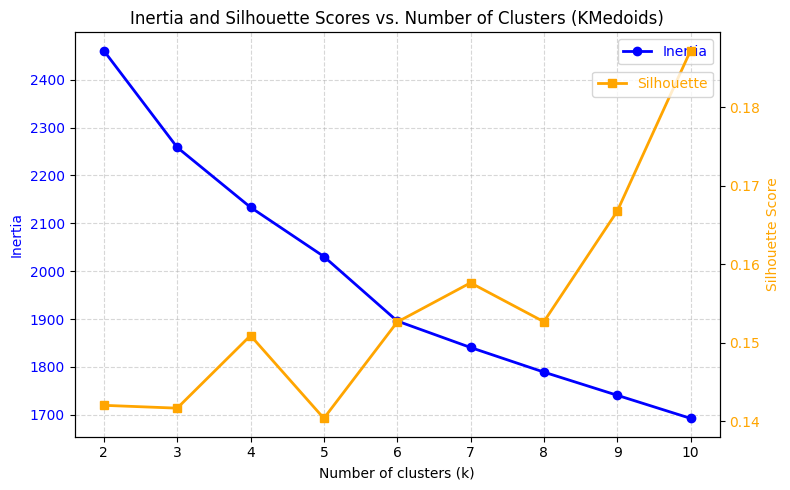

In [16]:
KMedoids_plotter(df_gower, lower_bound=2, upper_bound=10)

## DB SCAN 

In [ ]:
def DBScanner(X, X_gower, params_list):

    if len(params_list) == 0:
        raise ValueError("Wow!")

    silhouette_list = []
    db_index_list = []
    ch_score_list = []

    # iteracja po liczbie klastrów w celu wyznaczenia metryk

    for i, param in enumerate(tqdm(params_list)):
        db = DBSCAN(**param, metric = 'precomputed')
        labels = db.fit_predict(X_gower)

        
        unique_labels = set(labels)
        if len(unique_labels - {-1}) <= 1:
            print(f"param_nr_{i}: Outliers or only one cluster → metryki = 0")
            silhouette_list.append(0.0)
            db_index_list.append(0.0)
            ch_score_list.append(0.0)
        else:
           
            try:
                sil = silhouette_score(X, labels)
            except:
                sil = 0.0

            
            try:
                dbi = davies_bouldin_score(X, labels)
            except:
                dbi = 0.0

            
            try:
                chs = calinski_harabasz_score(X, labels)
            except:
                chs = 0.0

            print(f"param_nr_{i}: Silhouette = {sil:.4f}, "
                  f"Davies–Bouldin = {dbi:.4f}, "
                  f"Calinski–Harabasz = {chs:.4f}")

            silhouette_list.append(sil)
            db_index_list.append(dbi)
            ch_score_list.append(chs)


    param_labels = [f"param_nr_{i}" for i in range(len(params_list))]
    x_pos = np.arange(len(params_list))

    # wizualizacja metryk
    fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

  
    axs[0].scatter(x=x_pos, y=silhouette_list, color='tab:blue', edgecolor='k', alpha=0.7)
    axs[0].plot(x_pos, silhouette_list, color='tab:blue', linewidth=2)
    axs[0].set_ylabel('Silhouette Score', color='tab:blue')
    axs[0].tick_params(axis='y', labelcolor='tab:blue')
    axs[0].grid(alpha=0.3)

    
    axs[1].scatter(x=x_pos, y=db_index_list, color='tab:red', edgecolor='k', alpha=0.7)
    axs[1].plot(x_pos, db_index_list, color='tab:red', linewidth=2)
    axs[1].set_ylabel('Davies–Bouldin Index', color='tab:red')
    axs[1].tick_params(axis='y', labelcolor='tab:red')
    axs[1].grid(alpha=0.3)

   
    axs[2].scatter(x=x_pos, y=ch_score_list, color='tab:green', edgecolor='k', alpha=0.7)
    axs[2].plot(x_pos, ch_score_list, color='tab:green', linewidth=2)
    axs[2].set_ylabel('Calinski–Harabasz Score', color='tab:green')
    axs[2].tick_params(axis='y', labelcolor='tab:green')
    axs[2].grid(alpha=0.3)
    axs[2].set_xlabel('Parameter set index')

   
    plt.xticks(ticks=x_pos, labels=param_labels, rotation=45)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Aby znaleźć przedział/zakres wartości eps narysujemy wykres odległości od czwartego sąsiada dla każdego z punktów posortowane rosnąco

Z wykresu widać, że eps powinien być raczej nie większy niż 0.15

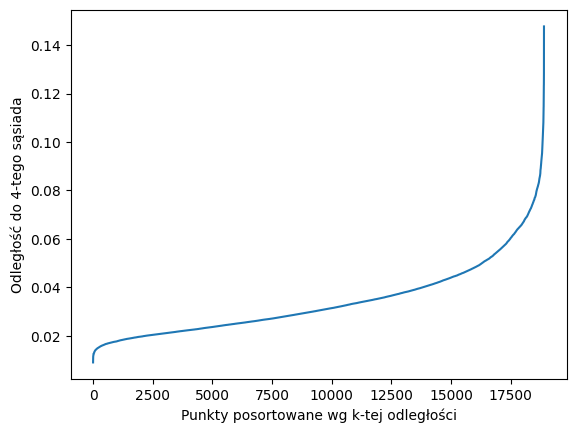

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


k = 4  # np. min_samples = 4
distances = np.sort(np.partition(df_gower, k, axis=1)[:, k])  # odległość do k-tego sąsiada
plt.plot(distances)
plt.xlabel("Punkty posortowane wg k-tej odległości")
plt.ylabel(f"Odległość do {k}-tego sąsiada")
plt.show()


Przetestujemy kilkanaście par parametrów

In [34]:
params_list = [dict(eps=i, min_samples=j) for i in [0.01,0.02,0.03, 0.1] for j in [3,5,10]]
params_list

[{'eps': 0.01, 'min_samples': 3},
 {'eps': 0.01, 'min_samples': 5},
 {'eps': 0.01, 'min_samples': 10},
 {'eps': 0.02, 'min_samples': 3},
 {'eps': 0.02, 'min_samples': 5},
 {'eps': 0.02, 'min_samples': 10},
 {'eps': 0.03, 'min_samples': 3},
 {'eps': 0.03, 'min_samples': 5},
 {'eps': 0.03, 'min_samples': 10},
 {'eps': 0.1, 'min_samples': 3},
 {'eps': 0.1, 'min_samples': 5},
 {'eps': 0.1, 'min_samples': 10}]

Dla niektórych zestawów DBScan nie poradził sobie zupełnie i wszystko zaklasteryzował do jednej grupy / uznał wszystkie wartości za outliery

Do dalszych prac wybierzemy zestaw param_nr_8: \{'eps': 0.03, 'min_samples': 10\}

  8%|▊         | 1/12 [00:05<01:04,  5.87s/it]

param_nr_0: Silhouette = -0.4111, Davies–Bouldin = 1.4413, Calinski–Harabasz = 2.1108


 17%|█▋        | 2/12 [00:07<00:32,  3.27s/it]

param_nr_1: Outliers or only one cluster → metryki = 0


 25%|██▌       | 3/12 [00:08<00:21,  2.40s/it]

...

param_nr_9: Outliers or only one cluster → metryki = 0


 92%|█████████▏| 11/12 [00:46<00:03,  3.80s/it]

param_nr_10: Outliers or only one cluster → metryki = 0


100%|██████████| 12/12 [00:49<00:00,  4.12s/it]


param_nr_11: Outliers or only one cluster → metryki = 0


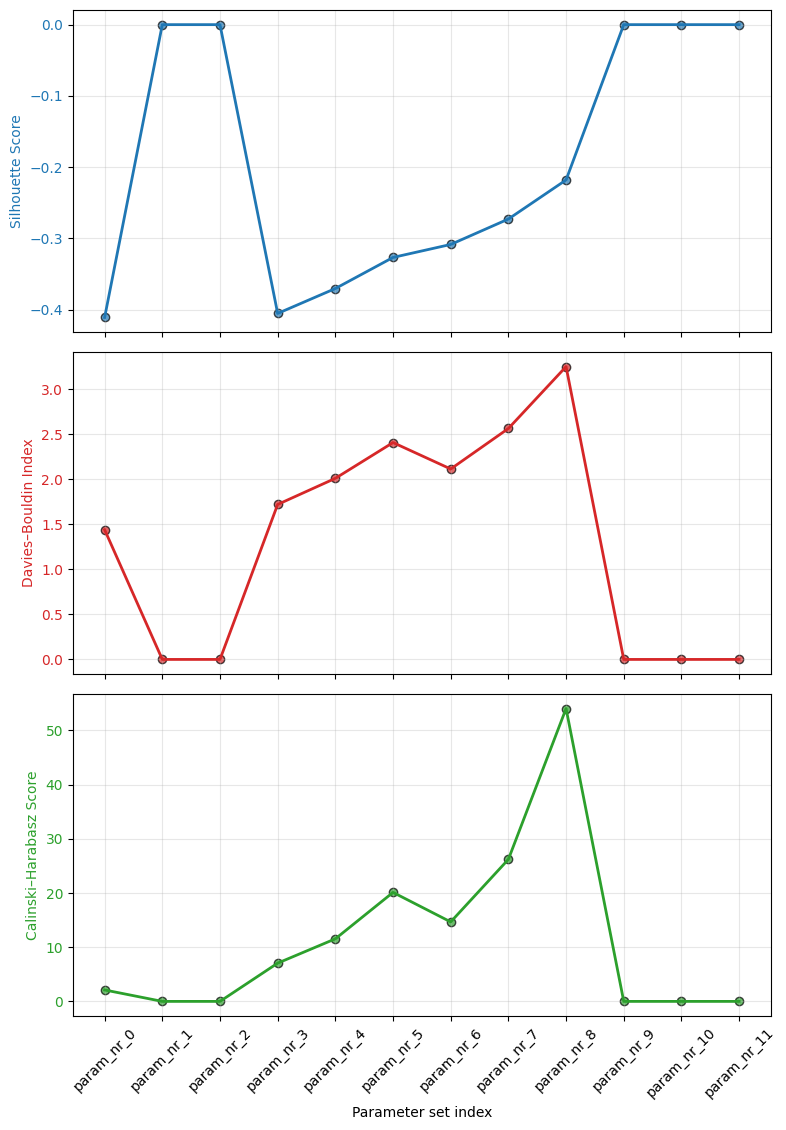

In [35]:
DBScanner(df, df_gower, params_list)

## Gaussian Mixture Models 

In [ ]:
def gmm_optimal_components(
    X,
    min_components=1,
    max_components=10,
    criterion='bic',
    random_state=42
):
   
    n_components_range = np.arange(min_components, max_components + 1)
    aic_values = []
    bic_values = []


    # iteracja po liczbie klastrów w celu wyznaczenia metryk
    for n in n_components_range:
        
        gmm = GaussianMixture(n_components=n, random_state=random_state)
        gmm.fit(X)

     
        aic = gmm.aic(X)
        bic = gmm.bic(X)
        aic_values.append(aic)
        bic_values.append(bic)

    # wykres metryk
    plt.figure(figsize=(8, 5))

    plt.plot(n_components_range, aic_values, marker='o', color='steelblue', label='AIC')
    plt.plot(n_components_range, bic_values, marker='s', color='salmon', label='BIC')


    plt.xticks(n_components_range)
    plt.xlabel('Liczba komponentów (n_components)')
    title = "Kryteria AIC i BIC vs. liczba komponentów (GMM)"
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    if criterion.lower() == 'aic':
        best_idx = np.argmin(aic_values)
        best_n = n_components_range[best_idx]
    elif criterion.lower() == 'bic':
        best_idx = np.argmin(bic_values)
        best_n = n_components_range[best_idx]
    else:
        raise ValueError("Kryterium musi być 'aic' lub 'bic'")

    print(f"\nOptimal {criterion.upper()}: {best_n}")
    return best_n

Wybierzemy 10 klastrów, ponieważ zarówno AIC i BIC osiągają minima w 10

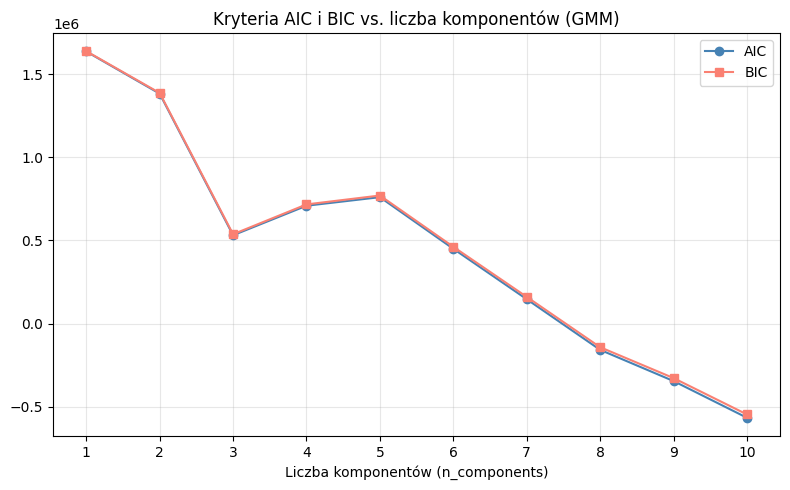


Optimal BIC: 10


10

In [22]:
gmm_optimal_components(df_famd,min_components=1,max_components=10)

## Mean shift 

In [ ]:
def meanshift_quality_plot(
    X,
    bandwidth_list,
    metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    cluster_all=True,
    n_jobs=None,
):
    
    results = {m: [] for m in metrics}
    n_clusters_list = []

    # iteracja bo bandwidth
    for bw in bandwidth_list:
        ms = MeanShift(bandwidth=bw, cluster_all=cluster_all, n_jobs=n_jobs)
        labels = ms.fit_predict(X)
        n_clusters = len(np.unique(labels))
        n_clusters_list.append(n_clusters)

        if n_clusters <= 1:
            for m in metrics:
                results[m].append(0.0)
            continue

        if "silhouette" in metrics:
            results["silhouette"].append(silhouette_score(X, labels))
        if "davies_bouldin" in metrics:
            results["davies_bouldin"].append(davies_bouldin_score(X, labels))
        if "calinski_harabasz" in metrics:
            results["calinski_harabasz"].append(
                calinski_harabasz_score(X, labels))

    # wykres metryk
    n_metrics = len(metrics)
    fig, axs = plt.subplots(
        n_metrics, 1, figsize=(8, 3 * n_metrics), sharex=True
    )

    if n_metrics == 1:
        axs = [axs]  

    colors = {
        "silhouette": "tab:blue",
        "davies_bouldin": "tab:red",
        "calinski_harabasz": "tab:green",
    }
    for ax, m in zip(axs, metrics):
        ax.plot(
            bandwidth_list,
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axs[-1].set_xlabel("Bandwidth")
    plt.suptitle("Miary jakości klasteryzacji vs. bandwidth", y=0.94)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    header = "bandwidth | n_clusters " + " ".join(f"| {m:^18s}" for m in metrics)
    print(header)
    print("-" * len(header))
    for i, bw in enumerate(bandwidth_list):
        row = f"{bw:9.3f} | {n_clusters_list[i]:10d} "
        for m in metrics:
            row += f"| {results[m][i]:18.4f} "
        print(row)


Do dalszych pracy wybierzemy **bandwidth = 15**

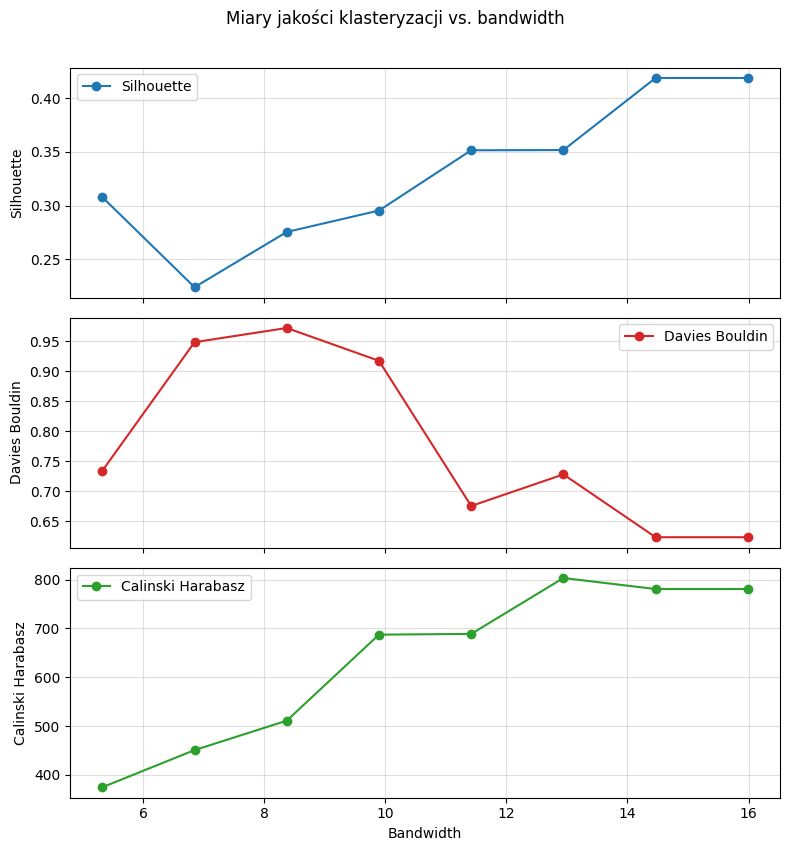

bandwidth | n_clusters |     silhouette     |   davies_bouldin   | calinski_harabasz 
-------------------------------------------------------------------------------------
    5.329 |        392 |             0.3078 |             0.7343 |           374.6765 
    6.852 |         86 |             0.2237 |             0.9483 |           450.7892 
    8.374 |         59 |             0.2753 |             0.9719 |           511.0368 
    9.897 |         26 |             0.2953 |             0.9173 |           687.1991 
   11.419 |         15 |             0.3516 |             0.6758 |           688.7252 
   12.942 |         13 |             0.3518 |             0.7283 |           803.1685 
   14.464 |         10 |             0.4191 |             0.6238 |           780.6204 
   15.987 |         10 |             0.4191 |             0.6238 |           780.6204 


In [ ]:
bw_est = estimate_bandwidth(df_famd, quantile=0.2, n_samples=300)
bw_values = np.linspace(bw_est * 0.5, bw_est * 1.5, 8)

meanshift_quality_plot(
        df_famd,
        bandwidth_list=bw_values,
        metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    )